In [1]:
import sys
print(sys.executable)

d:\Projects\Autism Detection\venv\Scripts\python.exe


In [ ]:
import pandas as pd; 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split, cross_val_predict, RandomizedSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier 
from imblearn.over_sampling import SMOTE 
import pickle  

In [3]:
df= pd.read_csv("../Data/raw/train.csv")


In [4]:
df.head()  

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    str    
 13  ethnicity        800 non-null    str    
 14  jaundice         800 non-null    str    
 15  austim           800 non-null    str    
 16  contry_of_res    800 non-null    str    
 17  used_app_before  800 non-nu

In [6]:
df['age'] =  df['age'].astype(int); 

In [7]:
pd.set_option('display.max_columns', None); 

In [8]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,1,7,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,0,23,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,0,43,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [9]:
for col in df.columns:
    numeric_features = ['ID', 'age', 'result']
    if col not in numeric_features:
        print(col, df[col].unique())
    

A1_Score [1 0]
A2_Score [0 1]
A3_Score [1 0]
A4_Score [0 1]
A5_Score [1 0]
A6_Score [0 1]
A7_Score [1 0]
A8_Score [0 1]
A9_Score [1 0]
A10_Score [1 0]
gender <StringArray>
['f', 'm']
Length: 2, dtype: str
ethnicity <StringArray>
[              '?',  'White-European', 'Middle Eastern ',        'Pasifika',
           'Black',          'Others',        'Hispanic',           'Asian',
         'Turkish',     'South Asian',          'Latino',          'others']
Length: 12, dtype: str
jaundice <StringArray>
['no', 'yes']
Length: 2, dtype: str
austim <StringArray>
['no', 'yes']
Length: 2, dtype: str
contry_of_res <StringArray>
[             'Austria',                'India',        'United States',
         'South Africa',               'Jordan',       'United Kingdom',
               'Brazil',          'New Zealand',               'Canada',
           'Kazakhstan', 'United Arab Emirates',            'Australia',
              'Ukraine',                 'Iraq',               'France',
        

In [10]:
# dropping ID and age_desc column 
df = df.drop(columns= ['ID', 'age_desc'])

In [11]:
df.head(2)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,2.255185,Self,0


In [12]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='str')

In [13]:
# here hong kong as well as china is present too - like they are same but diff location is there is dataset
# so we need to replace it 
df['contry_of_res'].unique()

<StringArray>
[             'Austria',                'India',        'United States',
         'South Africa',               'Jordan',       'United Kingdom',
               'Brazil',          'New Zealand',               'Canada',
           'Kazakhstan', 'United Arab Emirates',            'Australia',
              'Ukraine',                 'Iraq',               'France',
             'Malaysia',             'Viet Nam',                'Egypt',
          'Netherlands',          'Afghanistan',                 'Oman',
                'Italy',        'AmericanSamoa',              'Bahamas',
         'Saudi Arabia',              'Ireland',                'Aruba',
            'Sri Lanka',               'Russia',              'Bolivia',
           'Azerbaijan',              'Armenia',               'Serbia',
             'Ethiopia',               'Sweden',              'Iceland',
            'Hong Kong',               'Angola',                'China',
              'Germany',             

In [14]:
# defining the mapping dict for country maps 
mapping = {
    "Viet Nam": "Vietnam", 
     "AmericanSamoa": "'United States",
     "Hong Kong" : "China"
} 

df['contry_of_res'] =  df['contry_of_res'].replace(mapping); # df is permanently updated 


In [15]:
df['contry_of_res'].unique()

<StringArray>
[             'Austria',                'India',        'United States',
         'South Africa',               'Jordan',       'United Kingdom',
               'Brazil',          'New Zealand',               'Canada',
           'Kazakhstan', 'United Arab Emirates',            'Australia',
              'Ukraine',                 'Iraq',               'France',
             'Malaysia',              'Vietnam',                'Egypt',
          'Netherlands',          'Afghanistan',                 'Oman',
                'Italy',       ''United States',              'Bahamas',
         'Saudi Arabia',              'Ireland',                'Aruba',
            'Sri Lanka',               'Russia',              'Bolivia',
           'Azerbaijan',              'Armenia',               'Serbia',
             'Ethiopia',               'Sweden',              'Iceland',
                'China',               'Angola',              'Germany',
                'Spain',             

In [16]:
# lets see target column
df['Class/ASD'].value_counts()

Class/ASD
0    639
1    161
Name: count, dtype: int64

above it can be seen that the data is imbalance, non-autism people are more than autism so model can be boased. To solve this we can do "undersampling", "oversampling" 

Insights: 
(1): dropped age_desc and ID column 
(2): fixed countries name 
(3): class imbalance in the target column
(4): missing values in ethinicity and relation


In [17]:
df.shape

(800, 20)

In [18]:
df.head(2)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,2.255185,Self,0


In [19]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,27.963750,8.537303,0.201250
std,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.329827,4.807676,0.401185
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,-6.137748,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,5.306575,0.000000
50%,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.000000,9.605299,0.000000
75%,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.250000,12.514484,0.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.000000,15.853126,1.000000


Univariate analysis of numerical column

In [20]:
sns.set_theme(style= "darkgrid")


distribution plots using histogram 

27.96375
24.0


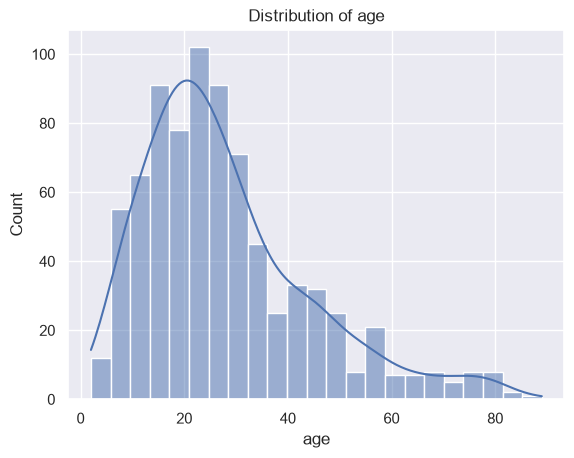

In [21]:
sns.histplot(df['age'], kde=True)
plt.title("Distribution of age")

age_mean = df['age'].mean(); 
age_median = df['age'].median()

print(age_mean)
print(age_median)

plt.show()

the above distribution is Right-skewed (larger tale to the right side)
hence mean > median
-- hence we prefer meadian to describe "age


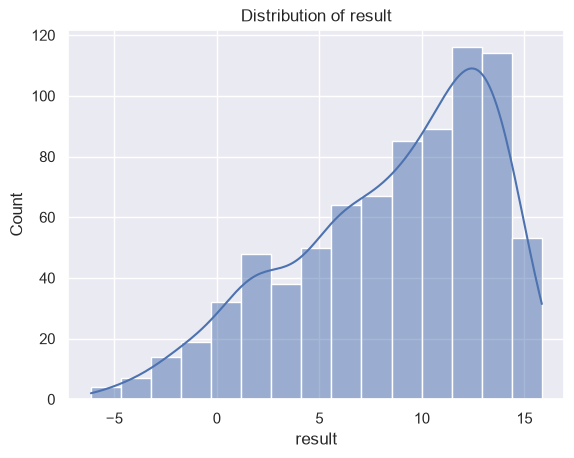

In [22]:
sns.histplot(df['result'], kde=True)
plt.title("Distribution of result")


plt.show()

Box-plots for identifying outliers in the numerical columns

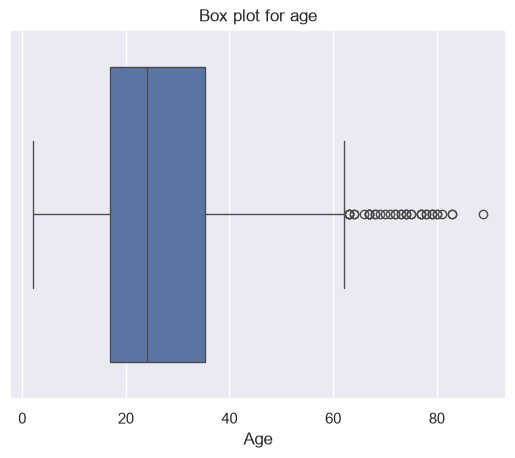

In [23]:
sns.boxplot(x =df['age'])
plt.title("Box plot for age")
plt.xlabel("Age")
plt.show()

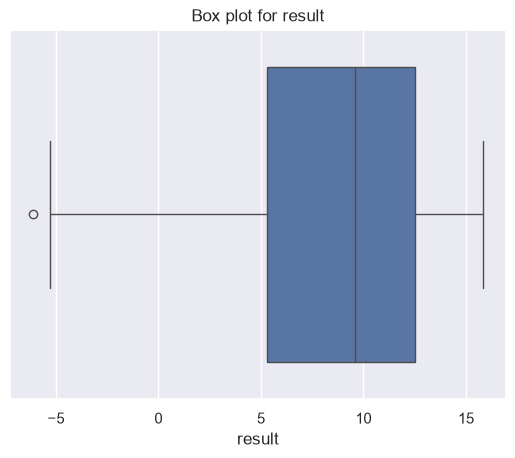

In [24]:
sns.boxplot(x =df['result'])
plt.title("Box plot for result")
plt.xlabel("result")
plt.show()

In [25]:
# count the outliers using IQR method 
Q1  =df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75) 

IQR = Q3 - Q1 

lowerbound = Q1 - 1.5 * IQR
upperbound = Q3 + 1.5 * IQR 

outliers = df[(df['age'] < lowerbound) | (df['age'] > upperbound)]

In [26]:
len(outliers)

39

there are total of 762 outliers in the dataset - later i will replace outliers using Median coz they are not affected by outliers

In [27]:
# count the outliers using IQR method 
Q1 = df['result'].quantile(0.25)
Q3 = df['result'].quantile(0.75) 

IQR = Q3 - Q1 

lowerbound = Q1 - 1.5 * IQR
upperbound = Q3 + 1.5 * IQR 

outliers = df[(df['result'] < lowerbound) | (df['result'] > upperbound)]

In [28]:
len(outliers)

1

Univariate analysis of Categorical column

In [29]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='str')

In [30]:
categorical_col = ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'relation']

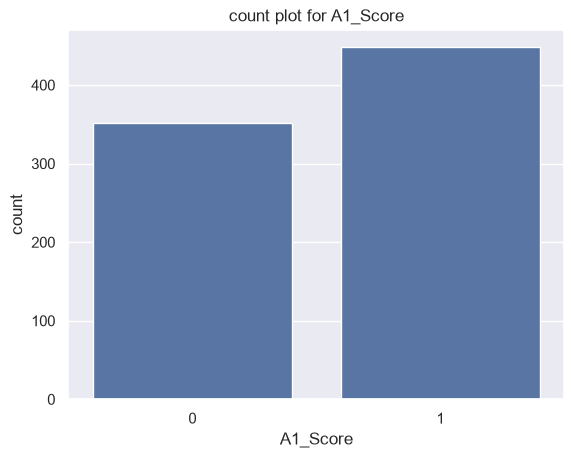

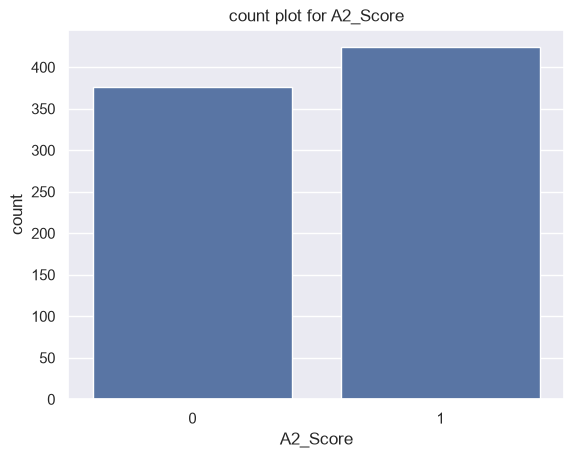

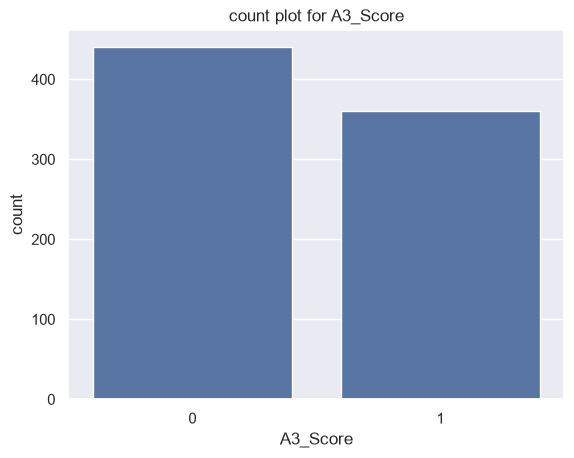

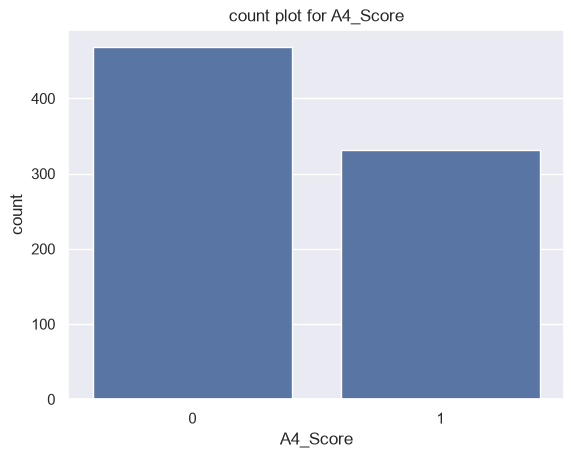

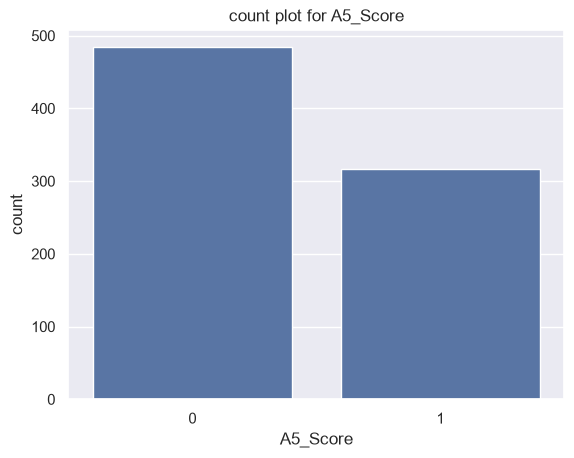

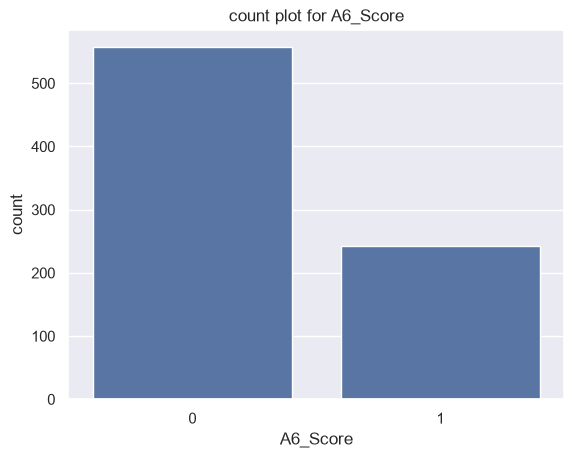

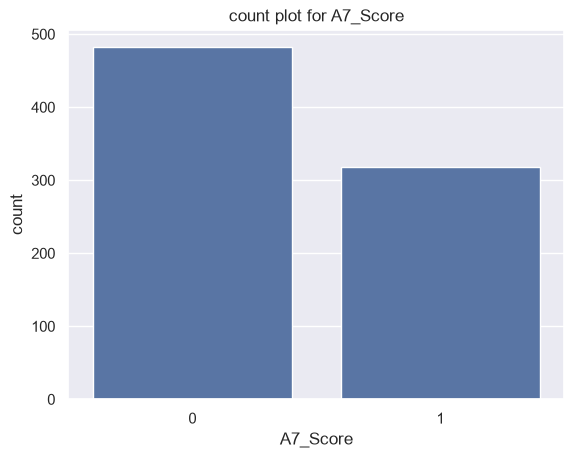

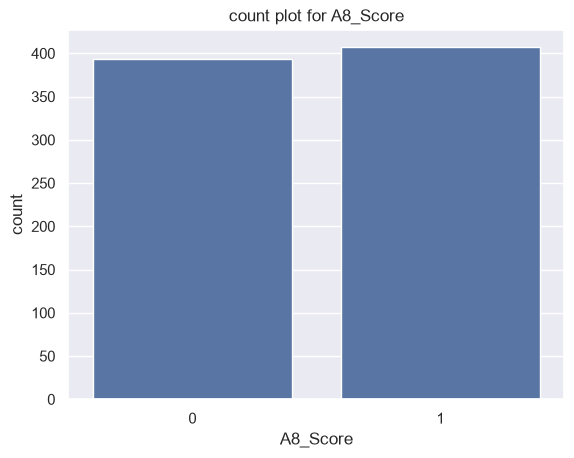

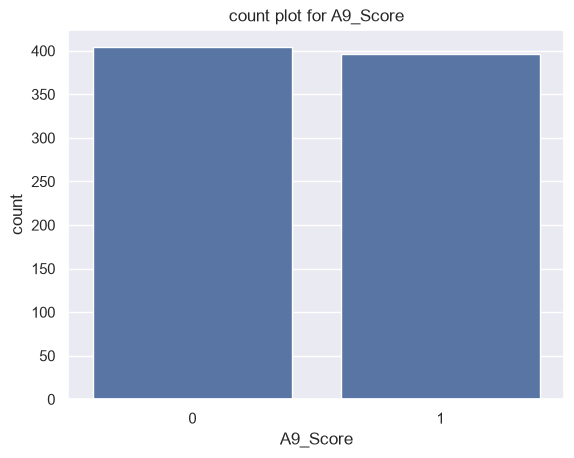

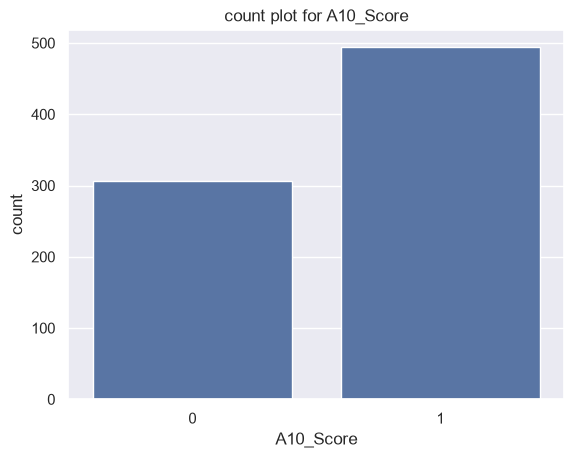

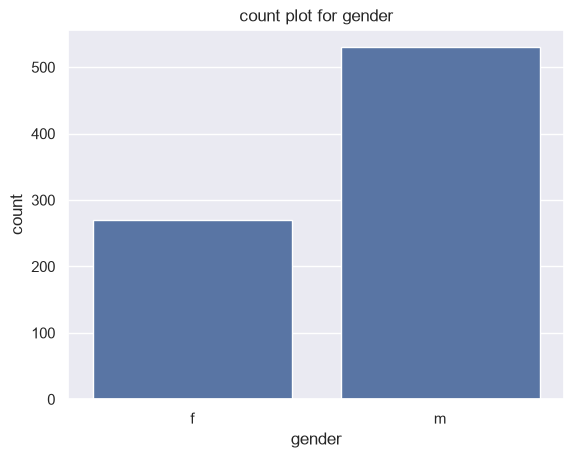

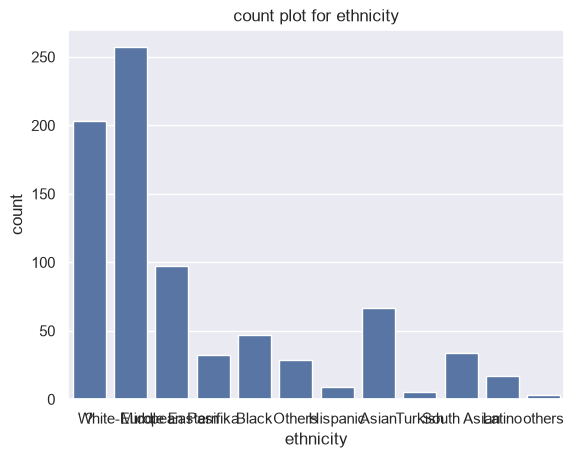

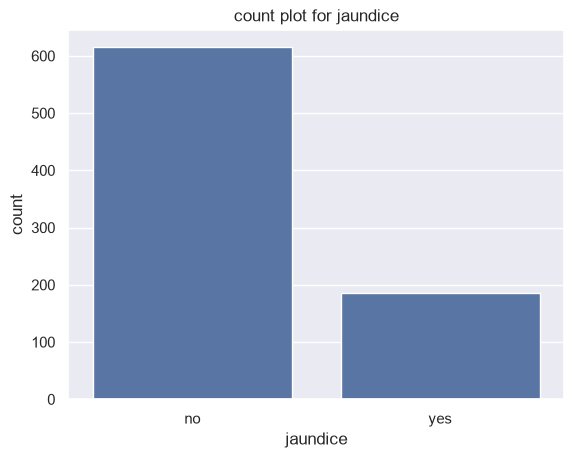

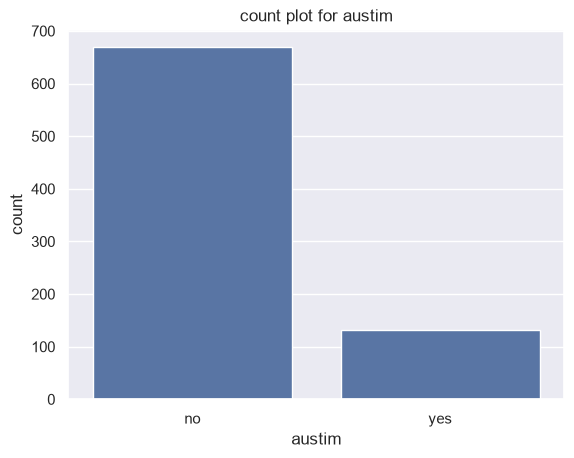

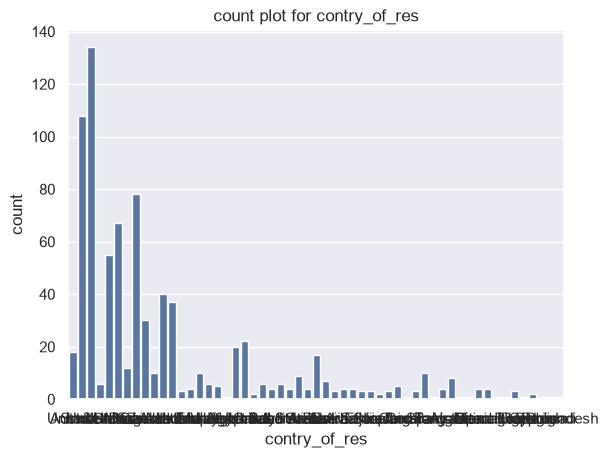

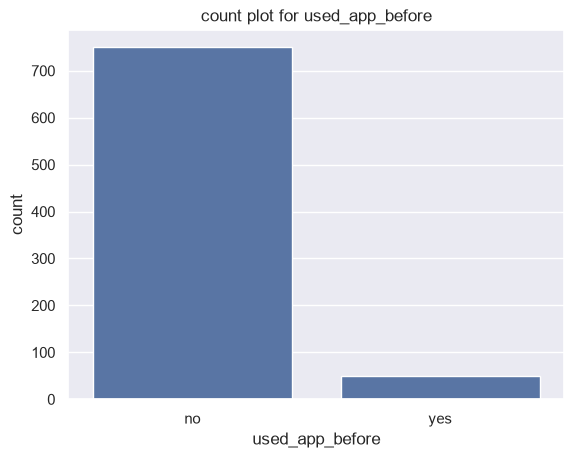

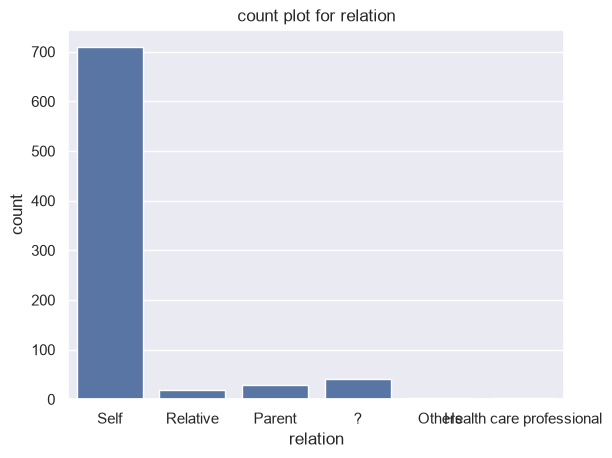

In [31]:
for col in categorical_col:
    sns.countplot(x = df[col])
    plt.title(f"count plot for {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

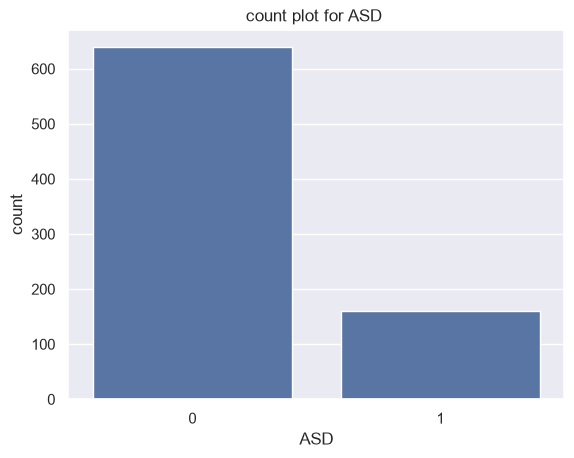

In [32]:
#count value plot for Class/ASD
sns.countplot(x = df['Class/ASD'])
plt.title(f"count plot for ASD ")
plt.xlabel("ASD")
plt.ylabel("count")
plt.show()

In [33]:
#handling missing values 
df['ethnicity'] = df['ethnicity'].replace({'?': "Others", 'others': "Others"})

In [34]:
df['ethnicity'].unique()

<StringArray>
[         'Others',  'White-European', 'Middle Eastern ',        'Pasifika',
           'Black',        'Hispanic',           'Asian',         'Turkish',
     'South Asian',          'Latino']
Length: 10, dtype: str

In [35]:
df['relation'].unique()

<StringArray>
['Self', 'Relative', 'Parent', '?', 'Others', 'Health care professional']
Length: 6, dtype: str

In [36]:
df['relation'] = df['relation'].replace({
    "?": "Others", 
    "Parent": 'Others', 
    "Relative": "Others",
    'Health care professional': "Others",   
})

In [37]:
df['relation'].unique()

<StringArray>
['Self', 'Others']
Length: 2, dtype: str

Label Encoding

In [38]:
#lets identify categorical column 
cat_col = df.select_dtypes(include=['object']).columns

C:\Users\shiva\AppData\Local\Temp\ipykernel_17988\3858173233.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df.select_dtypes(include=['object']).columns


In [39]:
print(cat_col)

Index(['gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'relation'],
      dtype='str')


Label Encoding

In [40]:
encoders = {}
for col in cat_col: 
    label_encoder = LabelEncoder()
    df[col] = label_encoder.fit_transform(df[col])
    encoders[col] = label_encoder

In [41]:
# i have deleted this 
#with open ("encoders.pkl", "wb") as f:
 #   pickle.dump(encoders, f)

In [42]:
# moved pickle file to Model folder
with open('../Models/encoders.pkl', "wb") as f:
    pickle.dump(encoders, f)

In [43]:
encoders

{'gender': LabelEncoder(),
 'ethnicity': LabelEncoder(),
 'jaundice': LabelEncoder(),
 'austim': LabelEncoder(),
 'contry_of_res': LabelEncoder(),
 'used_app_before': LabelEncoder(),
 'relation': LabelEncoder()}

In [44]:
df.head(3)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,0,5,0,0,7,0,6.351166,1,0
1,0,0,0,0,0,0,0,0,0,0,47,1,5,0,0,24,0,2.255185,1,0
2,1,1,1,1,1,1,1,1,1,1,7,1,9,0,1,53,0,14.851484,1,1


Bivariate analysis : we see the relationship between 2 variables 

we remove highly co-releated feature coz that will lead to highly multi-colinearity

We remove highly correlated features because they contain almost the same information. Keeping both can confuse some ML models, make feature importance unreliable, and increase multicollinearity without improving predictions.
You have two features:

Height (170 cm)
Height in meters (1.70 m)

Both tell the same information, just in different units. Keeping both doesn't give the model anything new.
Similarly, if two features are highly correlated, they are almost saying the same thing.

Why remove one?
It adds duplicate information.
Some models get confused about which feature is actually important.
The model becomes less stable and harder to interpret.

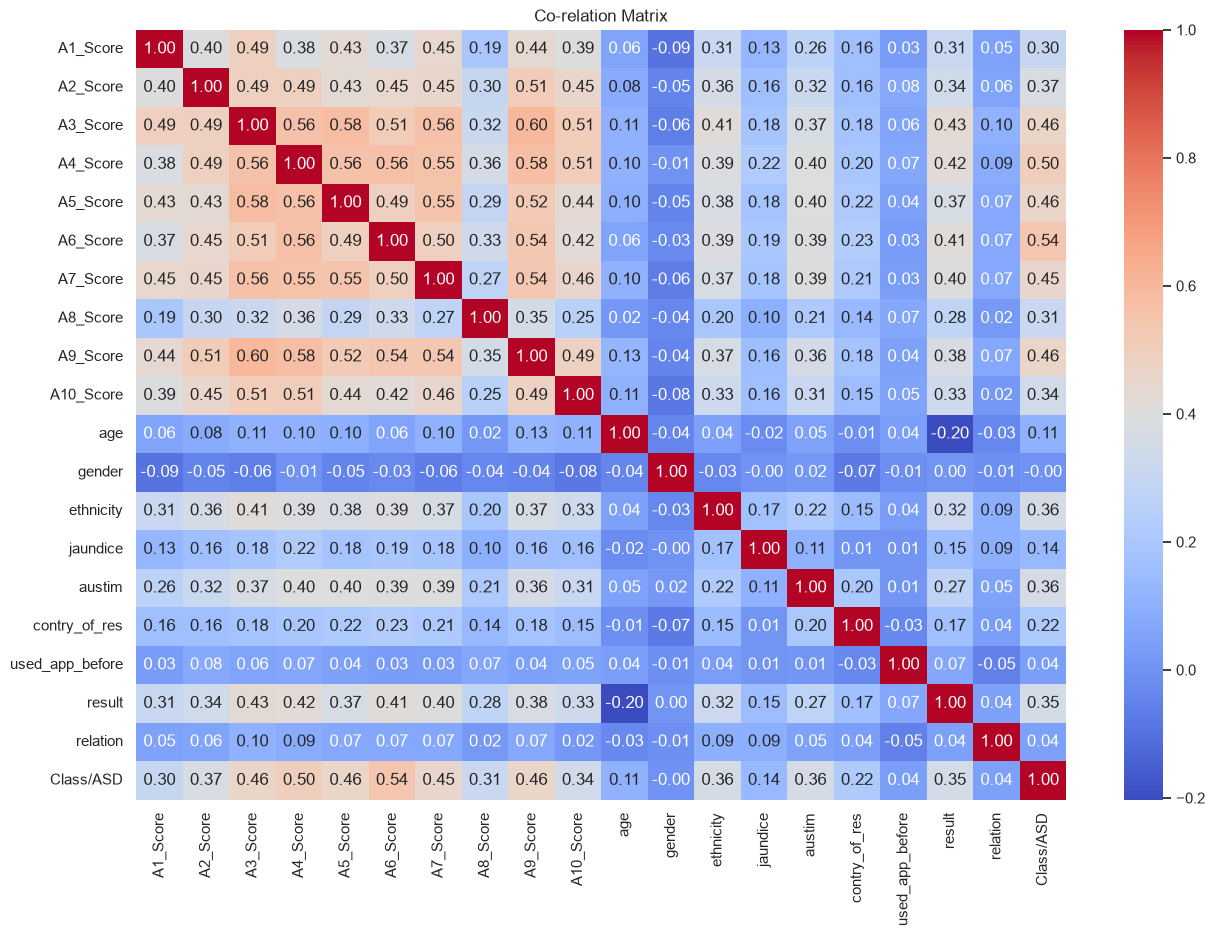

In [45]:
#co relation heatmap 
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True, cmap = "coolwarm", fmt=".2f")
plt.title("Co-relation Matrix")
plt.show()

"While checking the correlation matrix, we ignore the diagonal because every feature is perfectly correlated with itself. Then we look for feature pairs with a correlation above 0.8 or 0.9. If such a pair exists, they carry almost the same information, so we may drop one of them to avoid multicollinearity. In my dataset, no pair had such a high correlation, so I kept all the features."

**Data Preprocessing**

In [46]:
#replacing outliers with median 
def replace_outliers_with_median(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1 
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    median = df[column].median()
    
    #replacing median with outliers
    # this 'x' is for all the rows value in a column 
    df[column] = df[column].apply(lambda x: median if x < lower_bound or x > upper_bound else x)
    
    return df

In [47]:
#replace outliers in the age column 
df = replace_outliers_with_median(df, "age")


#lets do for result although it has 1 outliers only 
df = replace_outliers_with_median(df, 'result')

In [48]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38.0,0,5,0,0,7,0,6.351166,1,0
1,0,0,0,0,0,0,0,0,0,0,47.0,1,5,0,0,24,0,2.255185,1,0
2,1,1,1,1,1,1,1,1,1,1,7.0,1,9,0,1,53,0,14.851484,1,1
3,0,0,0,0,0,0,0,0,0,0,23.0,0,5,0,0,53,0,2.276617,1,0
4,0,0,0,0,0,0,0,0,0,0,43.0,1,5,0,0,45,0,-4.777286,1,0


Train - test split 

In [49]:
# x is all the feature column
x = df.drop(columns=["Class/ASD"])

# y is target column 
y = df["Class/ASD"]

In [50]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [51]:
print(Y_train.shape)
print(Y_test.shape)

(640,)
(160,)


In [52]:
Y_train.value_counts()

Class/ASD
0    515
1    125
Name: count, dtype: int64

now there is class imbalance between the training data


In [53]:
Y_test.value_counts()

Class/ASD
0    124
1     36
Name: count, dtype: int64

SMOTE for handling class imbalance 

In [54]:
smote = SMOTE(random_state=42)


In [55]:
X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)

In [56]:
print(Y_train_smote.shape)

(1030,)


In [57]:
print(Y_train_smote.value_counts())

Class/ASD
1    515
0    515
Name: count, dtype: int64


**Model Training**
 

In [62]:
#list of classifiers 
models = {
    "Decision tree": DecisionTreeClassifier(random_state=42), 
    "Random forest": RandomForestClassifier(random_state=42), 
    "XGboost": XGBClassifier(random_state = 42)
}

some keywords: cross validation, hyper pramater tuning 

In [77]:
from sklearn.model_selection import cross_val_score

In [103]:
cv_scores = {}
for model_name, model in models.items():
    print(f"Training {model_name} with default parameter....")
    scores = cross_val_score(model, X_train_smote, Y_train_smote, cv= 5, scoring="accuracy")
    cv_scores[model_name] = scores
    print(f"{model_name} cross-validation accuracy: {np.mean(scores):.2f} ")
    print("-"*50)
    

Training Decision tree with default parameter....
Decision tree cross-validation accuracy: 0.86 
--------------------------------------------------
Training Random forest with default parameter....
Random forest cross-validation accuracy: 0.92 
--------------------------------------------------
Training XGboost with default parameter....
XGboost cross-validation accuracy: 0.90 
--------------------------------------------------


These are cross-validation scores on the training data. They help you choose which model looks more promising.

In [104]:
cv_scores

{'Decision tree': array([0.82524272, 0.87378641, 0.87864078, 0.86893204, 0.85436893]),
 'Random forest': array([0.92718447, 0.91747573, 0.91747573, 0.90776699, 0.91747573]),
 'XGboost': array([0.8592233 , 0.92718447, 0.90776699, 0.90776699, 0.90776699])}

**Model Selection and hyperparameter tuning**

In [112]:
# initialising models 
Decision_tree = DecisionTreeClassifier(random_state=42)
Random_forest= RandomForestClassifier(random_state=42)
XGboost_classifier = XGBClassifier(random_state = 42)

In [126]:
#hyper parameter grids for RandomisedSearchCV

param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 10, 20, 30, 50, 70],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

param_grid_rf = {
    "n_estimators": [50, 100, 200, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
} 

param_grid_xg = {
    "n_estimators": [50, 100, 200, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.1, 0.2, 0.3],
    "subsample": [0.5, 0.7, 1.0],
    "colsample_bytree": [0.5, 0.7, 1.0]
}

In [114]:
# performing hyperparameter tuning for 3 based models 
random_search_dt = RandomizedSearchCV(estimator=Decision_tree, param_distributions=param_grid_dt, n_iter=20, cv=5, scoring="accuracy", random_state=42)
random_search_rf = RandomizedSearchCV(estimator=Random_forest, param_distributions=param_grid_rf, n_iter=20, cv=5, scoring="accuracy", random_state=42)
random_search_xg = RandomizedSearchCV(estimator=XGboost_classifier, param_distributions=param_grid_xg, n_iter=20, cv=5, scoring="accuracy", random_state=42)

In [115]:
print(type(Decision_tree))
print(Decision_tree)

<class 'sklearn.tree._classes.DecisionTreeClassifier'>
DecisionTreeClassifier(random_state=42)


In [117]:
#fit the models 
random_search_dt.fit(X_train_smote, Y_train_smote)
random_search_rf.fit(X_train_smote, Y_train_smote)
random_search_xg.fit(X_train_smote, Y_train_smote)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.5, 0.7, ...], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instanc

In [120]:
#print(random_search_dt.best_estimator_)
print(random_search_dt.best_score_)

#print(random_search_rf.best_estimator_)
print(random_search_rf.best_score_)

#print(random_search_xg.best_estimator_)
print(random_search_xg.best_score_)


0.8689320388349515
0.925242718446602
0.9126213592233011


In [121]:
# get the model with best score 
best_model = None 
best_score = 0 


if random_search_dt.best_score_ > best_score:
    best_model = random_search_dt.best_estimator_
    best_score = random_search_dt.best_score_
    
if random_search_rf.best_score_ > best_score:
    best_model = random_search_rf.best_estimator_
    best_score = random_search_rf.best_score_
    
if random_search_xg.best_score_ > best_score:
    best_model = random_search_xg.best_estimator_
    best_score = random_search_xg.best_score_ 


In [122]:
print(f"best model is: {best_model}")
print(f" best cross validation accuracy is: {best_score} ")

best model is: RandomForestClassifier(bootstrap=False, max_depth=20, n_estimators=50,
                       random_state=42)
 best cross validation accuracy is: 0.925242718446602 


**Saving the best Model**

In [123]:
# saving the best model 
with open('../Models/model.pkl', "wb") as f:
    pickle.dump(best_model, f)

**Evaluating on Test Data**

Accuracy Score:
 0.8125


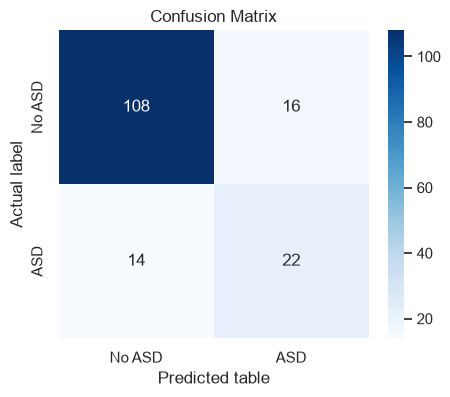

Classification report: 
               precision    recall  f1-score   support

           0       0.89      0.87      0.88       124
           1       0.58      0.61      0.59        36

    accuracy                           0.81       160
   macro avg       0.73      0.74      0.74       160
weighted avg       0.82      0.81      0.81       160



In [125]:
y_test_predict = best_model.predict(X_test)
print("Accuracy Score:\n", accuracy_score(Y_test, y_test_predict))
cm = confusion_matrix(Y_test, y_test_predict)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["No ASD", "ASD"], yticklabels=["No ASD", "ASD"])
plt.xlabel("Predicted table")
plt.ylabel("Actual label")
plt.title("Confusion Matrix")
plt.show()
print("Classification report: \n", classification_report(Y_test, y_test_predict))